# 01. 波・複素数・関数の内積

**この章のゴール**: フーリエ解析の「基底」を作る。正弦波の 3 つのパラメータ、
複素指数関数 $e^{i\theta}$、そして関数の内積と直交性を、図と計算で掴む。

## Big Picture

フーリエ解析は **関数版の線形代数** です。ベクトルを基底ベクトルの和で表すように、
関数を **波の和** で表します。そのために必要な道具は 3 つだけです。

1. **正弦波** — 最も単純な振動(基底の「向き」)
2. **複素指数関数** $e^{i\theta}$ — 正弦・余弦をまとめて扱う回転(Euler の公式)
3. **関数の内積** — 「その波がどれだけ含まれるか」を測るものさし

## Problem

複雑な信号 $f(t)$ から「周波数 $f_0$ の成分がどれだけ含まれるか」を取り出したい。
ベクトルなら内積 $\langle v, e_k\rangle$ で第 $k$ 成分が取れた。関数でも同じことを
したい — そのための内積と、互いに混ざらない基底(直交性)が必要になる。

## Intuition — 正弦波の 3 パラメータ

$$ x(t) = A\sin(2\pi f t + \phi) $$

- **振幅 $A$**: 波の大きさ
- **周波数 $f$**: どれくらい速く振動するか(Hz = 1 秒あたりの回数)
- **位相 $\phi$**: 波の横ずれ

下のスライダー(JupyterLab で動作)で 3 つを動かすと、波がどう変わるか体感できます。
静的環境では、その下の図が代表例(周波数・位相違い)を示します。

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

In [2]:
# Interactive (JupyterLab): drag amplitude / frequency / phase.
try:
    widgets.interactive_sine()
except Exception as e:
    print("interactive demo needs JupyterLab:", e)

interactive(children=(FloatSlider(value=1.0, description='amp', max=3.0), FloatSlider(value=3.0, description='…

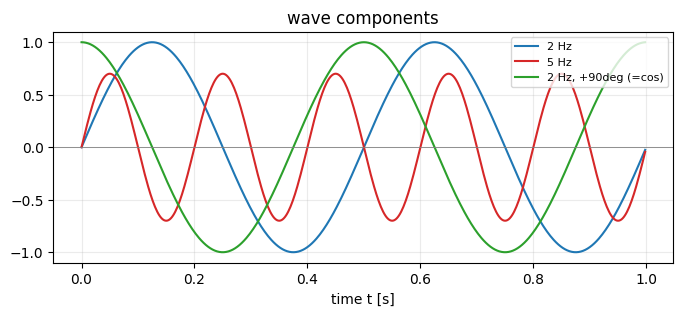

In [3]:
# Static fallback: same idea, three sines differing in frequency and phase.
t, _ = signals.time_grid(1.0, 500.0)
comps = [
    signals.sine(t, freq=2, amp=1.0, phase=0.0),
    signals.sine(t, freq=5, amp=0.7, phase=0.0),
    signals.sine(t, freq=2, amp=1.0, phase=np.pi / 2),  # phase-shifted = cosine
]
plotting.plot_components(t, comps, labels=["2 Hz", "5 Hz", "2 Hz, +90deg (=cos)"])
plt.show()

## Visualization — 複素指数関数は「回転」

Euler の公式

$$ e^{i\theta} = \cos\theta + i\sin\theta $$

は、$e^{i\theta}$ が複素平面上の **単位円を回る点** であることを意味します。
実部が余弦、虚部が正弦。だから $e^{i2\pi f t}$ は「周波数 $f$ で回転する位相子(phasor)」で、
正弦と余弦を一度に運ぶ便利な基底になります。

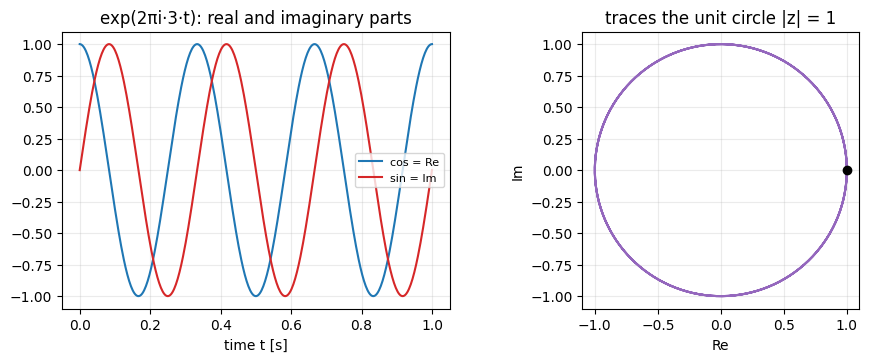

max |exp| = 1.0000000000000002  (always 1)


In [4]:
# The phasor exp(2πi f t): real & imaginary parts in time, and the unit circle.
t = np.linspace(0, 1, 400)
z = signals.complex_exponential(t, freq=3.0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(t, z.real, label="cos = Re", color="#1f77b4")
ax[0].plot(t, z.imag, label="sin = Im", color="#d62728")
ax[0].set_title("exp(2πi·3·t): real and imaginary parts")
ax[0].set_xlabel("time t [s]"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.25)

ax[1].plot(z.real, z.imag, color="#9467bd")
ax[1].scatter([1], [0], color="black", zorder=5)
ax[1].set_aspect("equal"); ax[1].set_title("traces the unit circle |z| = 1")
ax[1].set_xlabel("Re"); ax[1].set_ylabel("Im"); ax[1].grid(alpha=0.25)
plt.show()

print("max |exp| =", np.abs(z).max(), " (always 1)")

## Definition — 関数の内積と直交性

ベクトルの内積 $\langle u,v\rangle=\sum_k u_k\overline{v_k}$ を、関数に拡張します。

$$ \langle f, g \rangle = \int_a^b f(x)\,\overline{g(x)}\,dx $$

これで関数の「長さ」 $\|f\|=\sqrt{\langle f,f\rangle}$ と「角度」が定義できます。
区間 $[0,2\pi)$ 上で、複素指数の族 $\{e^{inx}\}_{n\in\mathbb{Z}}$ は **直交** します:

$$ \frac{1}{2\pi}\int_0^{2\pi} e^{imx}\,\overline{e^{inx}}\,dx = \delta_{mn} $$

直交とは「別々の成分が互いに混ざらずに測れる」性質です。これがあるから、
各周波数成分を内積一発で取り出せます。

## Computation — 直交性を数値で確かめる

基底 $e^{inx}$ を格子上でサンプリングし、内積(= 正規化した和)の行列(Gram 行列)を
作ると、**単位行列**になるはずです。

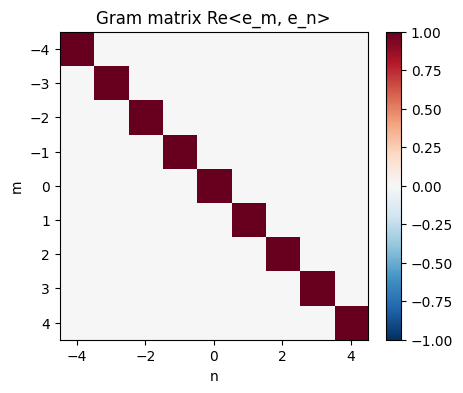

max off-diagonal magnitude: 4.570856460003506e-16


In [5]:
# Gram matrix of {exp(i n x)} on [0, 2π): should be the identity (orthonormal).
N = 512
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
ns = np.arange(-4, 5)
B = np.array([np.exp(1j * n * x) for n in ns])      # (9, N)
G = (B @ B.conj().T) / N                            # <e_m, e_n> with 1/(2π)∫ normalization

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(G.real, cmap="RdBu_r", vmin=-1, vmax=1,
               extent=[ns[0] - .5, ns[-1] + .5, ns[-1] + .5, ns[0] - .5])
ax.set_title("Gram matrix Re<e_m, e_n>")
ax.set_xlabel("n"); ax.set_ylabel("m")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

print("max off-diagonal magnitude:", np.abs(G - np.eye(len(ns))).max())

## Invariant / Energy — ノルムは「波のエネルギー」

$\|f\|^2=\langle f,f\rangle=\int |f|^2 dx$ は信号のエネルギーに対応します。
正弦波 $A\sin(2\pi f t)$ の 1 周期平均パワーは $A^2/2$ です。直交基底では、
全体のエネルギーが各成分のエネルギーの和になります(Parseval、03 章)。

## Failure Mode — 「1 周期分」で測らないと直交が崩れる

直交性は **積分区間が周期の整数倍** のときに成り立ちます。半端な区間で切り取ると
成分同士が混ざり(内積が 0 にならない)、後の章で出る **スペクトル漏れ**(06)の
原因になります。下で、整数周期と半端な区間の内積を比べてみます。

In [6]:
# <sin(2x), sin(3x)> over a full period (≈0) vs a truncated interval (≠0).
def inner(f, g, x):
    return np.trapezoid(f * g, x)

x_full = np.linspace(0, 2 * np.pi, 2000)
x_part = np.linspace(0, 2.3, 2000)            # not an integer number of periods
print("full period :", inner(np.sin(2 * x_full), np.sin(3 * x_full), x_full))
print("truncated   :", inner(np.sin(2 * x_part), np.sin(3 * x_part), x_part))

full period : 0.0
truncated   : 0.4603975409777834


## Application — 1 つの内積 = 1 つのフーリエ係数

信号を 1 つの基底波へ射影すると、その周波数成分の量(= フーリエ係数)が得られます。
例として $f(x)=3+2\cos 2x-\sin 5x$ から、$\cos 2x$ 成分の係数 $a_2=2$ を取り出します。

In [7]:
# Project f onto cos(2x): a_2 = (1/π) ∫ f(x) cos(2x) dx  ->  expect 2.
x = np.linspace(0, 2 * np.pi, 4096, endpoint=False)
f = 3 + 2 * np.cos(2 * x) - np.sin(5 * x)
a2 = 2 * np.mean(f * np.cos(2 * x))       # mean over a period = (1/2π)∫, ×2 for the trig norm
a0 = np.mean(f)                           # DC component
print("a0 (mean)      =", a0)             # -> 3
print("a2 (cos2 amp)  =", a2)             # -> 2
print("via trig_coeffs:", transforms.trig_coeffs(lambda t: 3 + 2*np.cos(2*t) - np.sin(5*t), 5)[0][2])

a0 (mean)      = 3.0
a2 (cos2 amp)  = 1.9999999999999996
via trig_coeffs: 1.9999999999999996


### 射影としてのフーリエ係数(可視化)

係数 $a_2$ は、信号 $f$ を基底波 $\cos 2x$ へ **射影** した成分の量です。赤が射影された成分
$a_2\cos 2x$ — 「$f$ の中にどれだけ $\cos 2x$ が含まれるか」を図にしたもの。

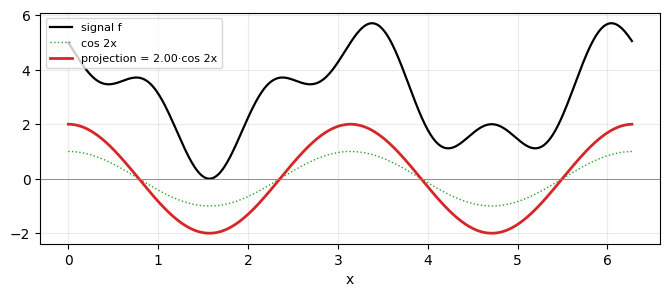

In [8]:
# A Fourier coefficient is a projection: the red curve is the cos(2x) content of f.
xx = np.linspace(0, 2 * np.pi, 600, endpoint=False)
f = 3 + 2 * np.cos(2 * xx) - np.sin(5 * xx)
a2 = 2 * np.mean(f * np.cos(2 * xx))
plotting.plot_projection(xx, f, np.cos(2 * xx), a2, basis_label="cos 2x")
plt.show()

## Exercises

1. **位相と余弦**: $\sin(\theta+\pi/2)=\cos\theta$ を Euler の公式から示し、数値でも確認せよ。
2. **直交の破れ**: 上の Gram 行列を区間 $[0, 2.3)$ で作ると単位行列からどれだけずれるか。
3. **エネルギー**: $A\sin(2\pi f t)$ の 1 周期平均パワーが $A^2/2$ になることを数値で確かめよ。
4. **射影**: $f(x)=x$($-\pi<x<\pi$、周期 $2\pi$)の $b_n=\langle f,\sin nx\rangle$ を数値計算し、
   $b_n=2(-1)^{n+1}/n$ と比べよ(のこぎり波、02 章への布石)。

## Advanced Notes

```{admonition} ヒルベルト空間 $L^2$
:class: note
内積 $\langle f,g\rangle=\int f\overline{g}$ を備えた二乗可積分関数の空間 $L^2[0,2\pi]$ は
**完備**(Cauchy 列が必ず収束する)で、$\{e^{inx}/\sqrt{2\pi}\}$ はその **正規直交基底**を成す。
「関数を波で展開する」とは、この基底による座標表示にほかならない。複素内積では
共役 $\overline{g}$ を取る点に注意(順序で複素共役が入れ替わる)。
```

- 直交性は「周期の整数倍」で積分するという条件に強く依存する。
- 完備性(基底が「足りている」こと)は、部分和が元の関数に $L^2$ で収束する根拠(03 章)。